# H2O end to end: fermions to exact sector compilation to KFAC

This example compiles the STO-3G CAS(2e,2o) active space of water to a
two-local HamiltonZero system, then
fine-tunes the released checkpoint for 10,000 KFAC steps and checks the
result against chemical accuracy ($1.6$ mHa). Using `hamiltonzero.fermionic`, we will take the following steps:

1. build the fermionic Hamiltonian from the packaged active-space integrals;
2. locate the invariant charge sector holding the ground state and verify
   the restriction by exact diagonalization;
3. encode the sector exactly on a two-local register (dense for
   $d \le 4$; one-hot with a *commuting* confinement penalty for larger
   sectors — never a perturbative gadget);
4. run the packaged fine-tune and evaluation;
5. test against the $1.6$ mHa chemical-accuracy threshold.

Run from a repository clone: the first cell places `src/` on `sys.path`,
so `pip install -e .` is optional as long as the runtime dependencies are
installed. Training expects the released checkpoint at `weights/hamiltonzero_v1.eqx` and at least one GPU; if a completed run already exists under `logs/fermionic_h2o_sector_e2e`,
the execution cell reuses it and everything else runs on CPU.

In [1]:
import json
import os
import sys
from pathlib import Path

os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("JAX_PLATFORMS", "cpu")

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / "pyproject.toml").exists():
    raise RuntimeError("run the notebook from inside the HamiltonZero repository")
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

RUN_DIR = ROOT / "logs" / "fermionic_h2o_sector_e2e"
RUN_DIR.mkdir(parents=True, exist_ok=True)
SYSTEM_PATH = RUN_DIR / "h2o_sector_2local.json"

N_MODES = 4
N_ELECTRONS = 2
CHEMICAL_ACCURACY = 1.6e-3
SEED = 1702

print(f"run directory: {RUN_DIR.relative_to(ROOT)}")

run directory: logs/fermionic_h2o_sector_e2e


## 1. The fermionic problem

The input is the number-conserving electronic Hamiltonian on $n$ spin-orbital
modes ($\alpha$ on even indices, $\beta$ on odd),

$$H_{\mathrm f} \;=\; E_0\,\mathbb 1 \;+\; \sum_{pq} h_{pq}\,a_p^\dagger a_q
\;+\; \sum_{pqrs} v_{pqrs}\,a_p^\dagger a_q^\dagger a_r a_s ,$$

with $h$ Hermitian and $[H_{\mathrm f}, \hat N]=0$. Here we have CAS(2e,2o), $n = 2N_o = 4$ modes and the charge sector $\hat N = N_e = 2$. The frozen core and nuclear repulsion of the
full molecule live entirely in $E_0$ and the dressed $h$. The active-space
integrals are input data, stored as *spatial-orbital* arrays in the JSON
record next to this notebook, and expand onto
spin orbitals as

$$h_{pq} = \delta_{\sigma_p \sigma_q}\, h^{\mathrm{spat}}_{PQ},
\qquad
v_{pqrs} = \delta_{\sigma_p \sigma_s}\,\delta_{\sigma_q \sigma_r}\,
v^{\mathrm{spat}}_{PQRS},$$

with $p = 2P + \sigma_p$ ($\alpha$ on even indices) and $v_{pqrs}$
multiplying $a_p^\dagger a_q^\dagger a_r a_s$ directly.

In [2]:
from hamiltonzero.fermionic import exact_reference, spinorb_from_spatial

record = json.loads((ROOT / "examples" / "h2o_sto3g_cas22.json").read_text())
print(f"{record['molecule']} {record['basis']} {record['active_space']}, "
      f"active spatial orbitals {record['active_spatial_orbitals']}")
one_spatial = np.array(record["one_body_spatial"])
two_spatial = np.array(record["two_body_spatial"])
E0 = float(record["constant"])
print("spatial one-body integrals (Eh):")
print(one_spatial)
print("unique spatial two-body values (Eh):")
print(sorted(set(two_spatial.ravel().tolist())))

one_body, two_body = spinorb_from_spatial(one_spatial, two_spatial)
print(f"expanded: {one_body.shape[0]} spin-orbital modes, "
      f"{np.count_nonzero(two_body)} two-body coefficients")

CASCI = exact_reference(one_body, two_body, E0, N_ELECTRONS)
print(f"CASCI reference (independent fixed-N ED): {CASCI:+.12f} Eh")
assert abs(CASCI - float(record["casci_energy"])) < 1e-9

H2O STO-3G CAS(2e,2o), active spatial orbitals [4, 5]
spatial one-body integrals (Eh):
[[-1.12256736  0.30273599]
 [ 0.30273599 -0.63971957]]
unique spatial two-body values (Eh):
[-0.036622290502, -0.01959390694, 0.030910292542, 0.30345252232, 0.312668951065, 0.402330794033]
expanded: 4 spin-orbital modes, 64 two-body coefficients
CASCI reference (independent fixed-N ED): -74.947182194336 Eh


## 2. Charge sectors and the exact restriction

Because $h, v$ preserve $\hat N_\alpha$ and $\hat N_\beta$, Fock space
splits into invariant blocks $\mathcal V_{k,l}$ with $\dim \mathcal V_{k,l}
= \binom{N_o}{k}\binom{N_o}{l}$. The $N_e$-electron ground state at spin
projection $m$ lives in the block of dimension

$$d(N_e, N_o; m) \;=\; \binom{N_o}{N_e/2+m}\binom{N_o}{N_e/2-m},$$

here $d(2,2;0) = 4$. Restriction to an invariant block is a change of
basis — **exact by linear algebra**, with none of the perturbative error a
finite-penalty gadget incurs. We verify everything by brute force: the
canonical anticommutation relations of the dense ladder representation,
and that the block ground energy reproduces CASCI.

In [3]:
from hamiltonzero.fermionic import car_residual, fock_matrix, ground_sector

print(f"maximum CAR residual: {car_residual(N_MODES):.1e}")

H_full = fock_matrix(one_body, two_body, E0)
sector, block = ground_sector(H_full, N_MODES, N_ELECTRONS)
print(f"ground sector: (N_alpha, N_beta) = ({sector.n_alpha}, {sector.n_beta}), "
      f"d = {sector.dimension}, Fock states {list(sector.fock_states)}")
block_ground = float(np.linalg.eigvalsh(block)[0])
print(f"sector ground: {block_ground:+.12f} Eh")
assert abs(block_ground - CASCI) < 1e-10

maximum CAR residual: 0.0e+00
ground sector: (N_alpha, N_beta) = (1, 1), d = 4, Fock states [3, 6, 9, 12]
sector ground: -74.947182194336 Eh


## 3. Exact two-local encoding

A $d \le 4$ block fits in two qubits *for free*: $\mathrm{Herm}(\mathbb
C^4)$ **is** the real span of the sixteen two-qubit Pauli words, so weight
$\le 2$ is automatic. Two spectator qubits are pinned to $|0\rangle$ by
weak $Z$ fields (they factorize exactly and carry the sector metadata), and
the identity component moves to a recorded scalar shift:

$$E_{\text{molecular}} \;=\; \texttt{energy\_scale}\cdot E_{\text{model}}
\;+\; \texttt{scalar\_shift}.$$

For $d > 4$ the library switches to a one-hot register where $|k\rangle\!
\langle l| \mapsto \tfrac12(X_kX_l + Y_kY_l)$ and the confinement penalty
$\lambda(\hat N_1 - 1)^2$ **commutes** with the encoded Hamiltonian — zero
bias at any finite $\lambda$, in contrast to perturbative penalty gadgets.
`compile_fermionic_sector` performs the
whole pipeline and returns numerical certificates for every claim.

In [4]:
from hamiltonzero.fermionic import compile_fermionic_sector

compiled = compile_fermionic_sector(
    one_body, two_body, E0, N_ELECTRONS, spin=None
)
print(f"{len(compiled.pauli_terms)} Pauli terms on {compiled.n_qubits} qubits")
for word, value in sorted(compiled.pauli_terms.items()):
    print(f"  {value:+.9f}  {word}")
print(f"scalar shift: {compiled.scalar_shift:+.9f} Eh; "
      f"energy scale: {compiled.energy_scale:.6f}")
print(f"compilation bias: {compiled.checks['bias_hartree']:+.2e} Eh; "
      f"compiled gap: {compiled.checks['gap_hartree']:.4f} Eh")
assert abs(compiled.to_hartree(compiled.raw_model_reference) - CASCI) < 1e-9

10 Pauli terms on 4 qubits
  -0.250000000  IIIZ
  -0.250000000  IIZI
  +0.017028384  IXII
  -0.196592978  IZII
  -0.017028384  XIII
  +0.246519797  XZII
  -0.061820585  YYII
  -0.196592978  ZIII
  -0.246519797  ZXII
  +0.054047350  ZZII
scalar shift: -73.890664059 Eh; energy scale: 1.000000
compilation bias: +1.42e-14 Eh; compiled gap: 0.4407 Eh


## 4. Fine-tune configuration

The released checkpoint is fine-tuned with the reference configuration: 256 walkers $\times$ 8 replica-exchange
chains, 2 decorrelation sweeps per step, KFAC with

$$\eta(t) \;=\; \frac{0.002}{1 + t/10^4},$$

damping $10^{-3}$, curvature EMA $0.99$, update periods $2/4$, norm
constraint $10^{-3}$, MAD clip width $5$, estimator $\mu = 2.86$,
$\varepsilon = 0.1$. The independent evaluation afterwards uses 512
measurement sweeps with deeper decorrelation (24 sweeps, burn-in 1024).

In [5]:
from hamiltonzero.data import load_system, save_system

system = compiled.spin_hamiltonian(
    nodes=("logical_0", "logical_1", "pin_2", "pin_3")
)
save_system(SYSTEM_PATH, system)
loaded = load_system(SYSTEM_PATH)
for expected, actual in zip(system.model_arrays(), loaded.model_arrays(), strict=True):
    np.testing.assert_allclose(actual, expected, rtol=0, atol=2e-6)
print(f"saved system -> {SYSTEM_PATH.relative_to(ROOT)} (system mu {system.mu:.6g})")

output_checkpoint = RUN_DIR / "h2o_sector_finetuned.eqx"
finetune_config = {
    "system": str(SYSTEM_PATH.relative_to(ROOT)),
    "checkpoint": "weights/hamiltonzero_v1.eqx",
    "output": str(output_checkpoint.relative_to(ROOT)),
    "steps": 10_000, "seed": SEED, "leaf_rank": 1536, "merge_rank": 1024,
    "mcmc": {"batch_size": 256, "replicas": 8, "steps": 2,
             "burn_in": 256, "burn_in_replica_steps": 2},
    "kfac": {"learning_rate_numerator": 0.002, "learning_rate_offset": 1.0,
             "learning_rate_decay_steps": 10_000.0, "curvature_ema": 0.99,
             "curvature_update_period": 2, "inverse_update_period": 4,
             "damping": 0.001, "minimum_damping": 0.0001,
             "norm_constraint": 0.001, "mad_clip_width": 5.0,
             "momentum": 0.0, "l2_regularization": 0.0},
    "energy": {"mu": 2.86, "eps": 0.1, "chunk_size": 512},
}
eval_config = {
    "system": str(SYSTEM_PATH.relative_to(ROOT)),
    "checkpoint": str(output_checkpoint.relative_to(ROOT)),
    "output": str((RUN_DIR / "eval_512").relative_to(ROOT)),
    "seed": SEED + 1, "measurements": 512, "contest": False,
    "large_n": False, "route_temperature": 4.0,
    "mcmc": {"batch_size": 256, "replicas": 8, "steps": 24,
             "burn_in": 1024, "burn_in_replica_steps": 2,
             "walker_chunk_size": 16},
    "energy": {"mu": 2.86, "eps": 0.1, "chunk_size": 512},
}
FINETUNE_CONFIG_PATH = RUN_DIR / "finetune.json"
EVAL_CONFIG_PATH = RUN_DIR / "eval.json"
FINETUNE_CONFIG_PATH.write_text(json.dumps(finetune_config, indent=2) + "\n")
EVAL_CONFIG_PATH.write_text(json.dumps(eval_config, indent=2) + "\n")
print(f"saved fine-tune config -> {FINETUNE_CONFIG_PATH.relative_to(ROOT)}")
print(f"saved evaluation config -> {EVAL_CONFIG_PATH.relative_to(ROOT)}")

saved system -> logs/fermionic_h2o_sector_e2e/h2o_sector_2local.json (system mu 0.708098)
saved fine-tune config -> logs/fermionic_h2o_sector_e2e/finetune.json
saved evaluation config -> logs/fermionic_h2o_sector_e2e/eval.json


## 5. Run fine-tuning and evaluation

Training and evaluation run through the packaged command line in fresh
subprocesses. This cell clears inherited multi-node network settings that
would misconfigure a single-node run, checks that GPUs are visible, and
renders live progress from the metrics stream. If the run directory
already holds a completed fine-tune and evaluation matching the current system and configuration, the cell reuses them;
delete `logs/fermionic_h2o_sector_e2e` to retrain from scratch.

In [6]:
import hashlib
import shutil
import subprocess
import sys
import threading
import time

METRICS_PATH = output_checkpoint.with_name(output_checkpoint.name + ".metrics.jsonl")
EVAL_DIR = RUN_DIR / "eval_512"
EVAL_METRICS_PATH = EVAL_DIR / "eval.metrics.jsonl"
EVAL_RESULT_PATH = EVAL_DIR / "eval.json"


def child_environment():
    environment = os.environ.copy()
    environment.pop("JAX_PLATFORMS", None)
    library_paths = [
        path for path in environment.get("LD_LIBRARY_PATH", "").split(":") if path
    ]
    removed = [p for p in library_paths
               if p == "/usr/local/gib" or p.startswith("/usr/local/gib/")]
    kept = [p for p in library_paths if p not in removed]
    if kept:
        environment["LD_LIBRARY_PATH"] = ":".join(kept)
    else:
        environment.pop("LD_LIBRARY_PATH", None)
    gib_profile = bool(removed)
    gib_profile = gib_profile or environment.get("NCCL_NET", "").lower() == "gib"
    gib_profile = gib_profile or "/gib/" in environment.get(
        "NCCL_TUNER_CONFIG_PATH", ""
    ).lower()
    if gib_profile:
        for name in sorted(environment):
            if name.startswith("NCCL_"):
                environment.pop(name)
    for name in ("JAX_COORDINATOR_ADDRESS", "JAX_PROCESS_COUNT",
                 "JAX_PROCESS_INDEX", "JAX_LOCAL_DEVICE_IDS"):
        environment.pop(name, None)
    environment["PYTHONUNBUFFERED"] = "1"
    environment["PYTHONPATH"] = str(ROOT / "src")
    return environment


def run_hamiltonzero(mode, config_path, total, description, metrics_file):
    command = [sys.executable, "-m", "hamiltonzero.cli", mode, str(config_path)]
    print("$ python -m hamiltonzero.cli " + mode + " "
          + str(config_path.relative_to(ROOT)))
    captured = []
    process = subprocess.Popen(
        command, cwd=ROOT, env=ENVIRONMENT, stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT, text=True, bufsize=1,
    )

    def pump():
        for line in process.stdout:
            captured.append(line.rstrip())

    reader = threading.Thread(target=pump, daemon=True)
    reader.start()
    report_every = max(1, total // 20)
    reported = -1
    last_step = -1
    try:
        while True:
            finished = process.poll() is not None
            if metrics_file.exists():
                for line in reversed(metrics_file.read_text().splitlines()):
                    try:
                        row = json.loads(line)
                    except json.JSONDecodeError:
                        continue
                    if row.get("step") is not None and row.get("energy") is not None:
                        last_step = int(row["step"])
                        if last_step - reported >= report_every or (
                            finished and last_step > reported
                        ):
                            print(f"{description}: step {last_step + 1}/{total}  "
                                  f"energy={row['energy']:+.8f}  "
                                  f"std={row['energy_std']:.2e}")
                            reported = last_step
                    break
            if finished:
                break
            time.sleep(2.0)
        reader.join(timeout=15)
        if process.returncode:
            print("\n".join(captured[-40:]))
            raise subprocess.CalledProcessError(process.returncode, command)
        if last_step + 1 != total:
            raise RuntimeError(f"{mode} recorded {last_step + 1}/{total} steps")
    except BaseException:
        process.terminate()
        process.wait(timeout=30)
        raise


STAMP_PATH = RUN_DIR / "run_stamp.json"
SIDECAR_PATH = output_checkpoint.with_name(output_checkpoint.name + ".json")
CODE_DIGEST = hashlib.sha256(
    b"".join(
        path.read_bytes()
        for path in sorted((ROOT / "src" / "hamiltonzero" / "fermionic").glob("*.py"))
    )
).hexdigest()
DIGEST = hashlib.sha256(
    SYSTEM_PATH.read_bytes()
    + json.dumps(finetune_config, sort_keys=True).encode()
    + json.dumps(eval_config, sort_keys=True).encode()
    + CODE_DIGEST.encode()
).hexdigest()
STAMP = json.loads(STAMP_PATH.read_text()) if STAMP_PATH.exists() else {}
COMPLETE = (
    METRICS_PATH.exists()
    and output_checkpoint.exists()
    and SIDECAR_PATH.exists()
    and EVAL_RESULT_PATH.exists()
    and EVAL_METRICS_PATH.exists()
    and len(METRICS_PATH.read_text().splitlines()) >= 10_000
    and len([l for l in EVAL_METRICS_PATH.read_text().splitlines() if l.strip()]) == 512
    and STAMP.get("sha256") == DIGEST
    and STAMP.get("checkpoint_sha256")
    == hashlib.sha256(output_checkpoint.read_bytes()).hexdigest()
)
if COMPLETE:
    print(f"completed run found in {RUN_DIR.relative_to(ROOT)}; "
          "artifacts match the current system and configuration")
else:
    ENVIRONMENT = child_environment()
    probe = subprocess.run(
        [sys.executable, "-c",
         "import jax; print(len([d for d in jax.devices() "
         "if d.platform in ('gpu', 'tpu')]))"],
        cwd=ROOT, env=ENVIRONMENT, text=True, capture_output=True, timeout=120,
    )
    n_accelerators = int(probe.stdout.strip().splitlines()[-1])
    print(f"visible accelerators: {n_accelerators}")
    if n_accelerators < 1:
        raise RuntimeError("run this notebook inside a GPU allocation")
    for path in (output_checkpoint, METRICS_PATH):
        if path.exists():
            path.unlink()
    if EVAL_DIR.exists():
        shutil.rmtree(EVAL_DIR)
    run_hamiltonzero("finetune", FINETUNE_CONFIG_PATH, 10_000, "fine-tune",
                     METRICS_PATH)
    run_hamiltonzero("eval", EVAL_CONFIG_PATH, 512, "evaluate",
                     EVAL_METRICS_PATH)
    STAMP_PATH.write_text(json.dumps({
        "sha256": DIGEST,
        "checkpoint_sha256": hashlib.sha256(output_checkpoint.read_bytes()).hexdigest(),
    }) + "\n")

visible accelerators: 4
$ python -m hamiltonzero.cli finetune logs/fermionic_h2o_sector_e2e/finetune.json


fine-tune: step 540/10000  energy=-1.05669928  std=2.93e-03


fine-tune: step 1069/10000  energy=-1.05654693  std=1.94e-03


fine-tune: step 1603/10000  energy=-1.05651379  std=1.31e-03


fine-tune: step 2104/10000  energy=-1.05660152  std=8.79e-04


...

evaluate: step 428/512  energy=-1.05650377  std=3.79e-04


evaluate: step 453/512  energy=-1.05647516  std=3.31e-04


evaluate: step 479/512  energy=-1.05651426  std=5.25e-04


evaluate: step 505/512  energy=-1.05650246  std=4.46e-04


evaluate: step 512/512  energy=-1.05654466  std=4.79e-04


## 6. Training trace, evaluation, and the accuracy checks

The first figure is the training trace: 50-step window means of the
sampled energy, with the shading giving the sample standard deviation
across the 256 cold-chain walker local energies (sampling spread at fixed
parameters, not run-to-run uncertainty). The second figure is the
independent evaluation of the final checkpoint: 512 measurement sweeps
with deeper decorrelation, plotted per measurement. One check closes the
example: the upper confidence bound on the error must lie inside the
threshold, $|E_{\mathrm{eval}} - E_{\mathrm{CASCI}}| + 2 \times
\mathrm{SEM} < 1.6$ mHa, which requires both accuracy and enough
statistical resolution at once.

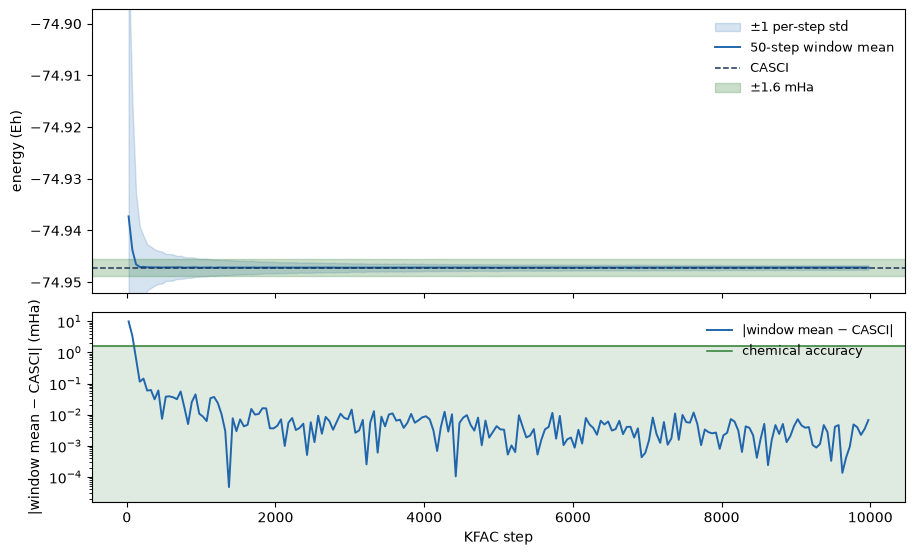

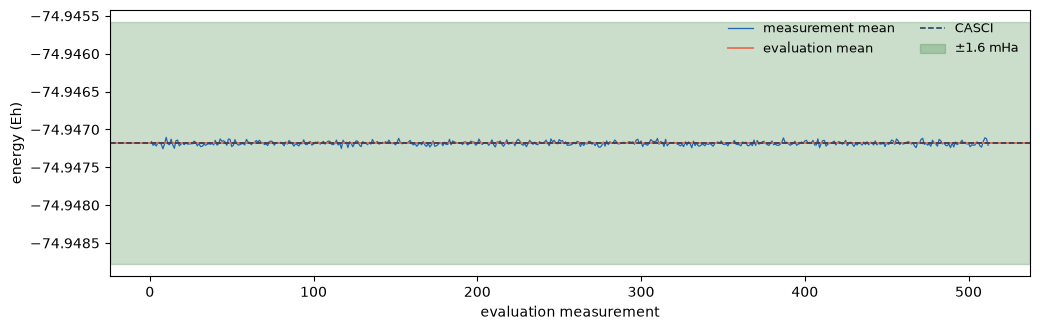

mean over the last 500 training steps: -74.947181600 Eh (+0.0006 mHa from CASCI)
independent evaluation, 512 measurements: -74.947182018 Eh (+0.0002 +/- 0.0012 mHa)
|gap| + 2 x SEM: 0.0025 mHa
within chemical accuracy (|gap| + 2 x SEM < 1.6 mHa): yes


In [7]:
rows = [
    json.loads(line) for line in METRICS_PATH.read_text().splitlines()
]
rows = [
    row for row in rows
    if row.get("step") is not None and row.get("energy") is not None
]
step_index = np.array([int(row["step"]) for row in rows])
assert (np.diff(step_index) == 1).all(), (
    "metrics file holds more than one training run; "
    "delete the run directory and rerun"
)
raw = np.array([row["energy"] for row in rows])
std = np.array([row["energy_std"] for row in rows])
energy = compiled.to_hartree(raw)
window = 50
n_bins = len(energy) // window
bins = energy[: n_bins * window].reshape(n_bins, window).mean(axis=1)
std_bins = std[: n_bins * window].reshape(n_bins, window).mean(axis=1)
steps = step_index[: n_bins * window].reshape(n_bins, window).mean(axis=1)

figure, (ax_energy, ax_error) = plt.subplots(
    2, 1, figsize=(10.5, 6.4), sharex=True,
    gridspec_kw={"height_ratios": [3, 2], "hspace": 0.08},
)
ax_energy.fill_between(steps, bins - std_bins * compiled.energy_scale,
                       bins + std_bins * compiled.energy_scale,
                       color="#2166AC", alpha=0.18,
                       label="$\\pm1$ per-step std")
ax_energy.plot(steps, bins, color="#2166AC", lw=1.4,
               label="50-step window mean")
ax_energy.axhline(CASCI, color="#1D3557", ls="--", lw=1.1, label="CASCI")
ax_energy.axhspan(CASCI - CHEMICAL_ACCURACY, CASCI + CHEMICAL_ACCURACY,
                  color="#2E7D32", alpha=0.25, label="$\\pm1.6$ mHa")
ax_energy.set_ylim(CASCI - 0.005, CASCI + 0.05)
ax_energy.set_ylabel("energy (Eh)")
ax_energy.legend(loc="upper right", frameon=False, fontsize=9)
gap_bins = np.abs(bins - CASCI) * 1e3
positive = gap_bins[gap_bins > 0]
floor = float(positive.min()) / 3.0
ax_error.plot(steps, gap_bins, color="#2166AC", lw=1.4,
              label="|window mean $-$ CASCI|")
ax_error.axhline(1.6, color="#2E7D32", lw=1.1, label="chemical accuracy")
ax_error.axhspan(floor, 1.6, color="#2E7D32", alpha=0.15)
ax_error.set_yscale("log")
ax_error.set_ylim(bottom=floor)
ax_error.set_ylabel("|window mean $-$ CASCI| (mHa)")
ax_error.set_xlabel("KFAC step")
ax_error.legend(loc="upper right", frameon=False, fontsize=9)
plt.show()

eval_means = compiled.to_hartree(np.array([
    json.loads(line)["energy"]
    for line in EVAL_METRICS_PATH.read_text().splitlines()
]))
evaluation = json.loads(EVAL_RESULT_PATH.read_text())
eval_energy = compiled.to_hartree(float(evaluation["energy"]))
figure_eval, ax_eval = plt.subplots(figsize=(10.5, 3.4))
ax_eval.plot(np.arange(1, len(eval_means) + 1), eval_means,
             color="#2166AC", lw=0.9, label="measurement mean")
ax_eval.axhline(eval_energy, color="#E76F51", lw=1.3,
                label="evaluation mean")
ax_eval.axhline(CASCI, color="#1D3557", ls="--", lw=1.1, label="CASCI")
ax_eval.axhspan(CASCI - CHEMICAL_ACCURACY, CASCI + CHEMICAL_ACCURACY,
                color="#2E7D32", alpha=0.25, label="$\\pm1.6$ mHa")
ax_eval.set_xlabel("evaluation measurement")
ax_eval.set_ylabel("energy (Eh)")
ax_eval.ticklabel_format(axis="y", useOffset=False)
ax_eval.legend(loc="upper right", frameon=False, fontsize=9, ncols=2)
figure_eval.tight_layout()
plt.show()

trailing = compiled.to_hartree(raw[-500:].mean())
trailing_gap = (trailing - CASCI) * 1e3
eval_sem = (
    float(eval_means.std(ddof=1) / np.sqrt(len(eval_means))) * 1e3
)
eval_gap = (eval_energy - CASCI) * 1e3
print(f"mean over the last 500 training steps: {trailing:+.9f} Eh "
      f"({trailing_gap:+.4f} mHa from CASCI)")
print(f"independent evaluation, {len(eval_means)} measurements: "
      f"{eval_energy:+.9f} Eh ({eval_gap:+.4f} +/- {eval_sem:.4f} mHa)")
combined = abs(eval_gap) + 2.0 * eval_sem
print(f"|gap| + 2 x SEM: {combined:.4f} mHa")
print("within chemical accuracy (|gap| + 2 x SEM < 1.6 mHa):",
      "yes" if combined < CHEMICAL_ACCURACY * 1e3 else "no")
assert combined < CHEMICAL_ACCURACY * 1e3